<a href="https://colab.research.google.com/github/Saifullah785/machine-learning-engineer-roadmap/blob/main/lecture_5_online_ml_sklearn_code_demo/Day_05_Online_vs_Offline_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 # 🔥 The Pulse of Learning – Online vs. Offline Machine Learning 🚀

---

### **The Story Begins: When Time Never Stops, Should Your Model?**

Imagine you're the lead data scientist at a cutting-edge financial institution. Your mission: build a fraud detection system. Every second, thousands of transactions flow in – legitimate purchases, suspicious transfers, anomalies lurking in the digital shadows. Your model needs to be a vigilant guard, always on, always learning.

Now, picture another scenario: you're forecasting next quarter's sales for a retail giant. You have years of historical data, neatly packaged and ready for analysis. The forecast is critical, but it's not a real-time, second-by-second decision.

Two vastly different worlds, two distinct approaches to machine learning. Should your model learn once, on a colossal batch of data, and then stand sentinel? Or should it be a nimble, ever-evolving entity, constantly absorbing new information and adapting in real-time, like a living organism?

This isn't just a technical question; it's a fundamental choice that dictates the very soul of your AI system. It's the difference between a static snapshot and a dynamic, continuous learning journey.

### **🎯 Notebook Goal:**

By the end of this masterclass, you will not only understand the theoretical underpinnings of Online and Offline (Batch) Learning but also **feel** their practical implications. We'll demystify **WHEN** and **WHY** to choose each approach, arming you with the intuition and code to build models that truly thrive in the real world.

Prepare for a deep dive, a hands-on project, and a story that will make you say: "Now I truly understand the pulse of machine learning."


---

# 📖 Story Setup: The Static vs. Dynamic World

Every machine learning problem lives in a context. This context is primarily defined by the nature of the data it encounters. Are we dealing with a world that largely stands still, or one that's in perpetual motion?

# **🌍 The Static World (Offline Learning Domain)**

In this realm, data is often collected over a period, then frozen. It's like taking a photograph. Once the photo is taken, it doesn't change. You analyze it, extract insights, and make decisions based on that fixed image.

*   **Relatable Examples:**
    *   **Netflix's Annual Content Strategy:** Deciding which original shows to greenlight for the *next year* based on *past viewing patterns*. The data for the decision is historical and fixed at the time of analysis.
    *   **Census Data Analysis:** Government agencies analyze population demographics collected over several years to inform policy, not real-time changes.
    *   **Historical Stock Market Research:** Studying decades of stock prices to identify long-term trends and inform *future investment strategies*, not real-time trading.

Here, a model can be trained once on this complete, static dataset. Its job is to generalize from that fixed past to predict a relatively stable future.

# **⚡ The Dynamic World (Online Learning Domain)**

This is a world of constant flux, where data streams in ceaselessly. It's less a photograph and more a live video feed. Information arrives sequentially, and decisions often need to be made instantaneously, adapting to the latest events.

*   **Relatable Examples:**
    *   **Real-time Stock Trading Algorithms:** Prices change every millisecond, and models must react instantly to new market data to execute trades.
    *   **Banking Fraud Detection:** Every transaction is new data. A fraudulent pattern might emerge and vanish quickly, requiring the system to learn and adapt with each new event.
    *   **Social Media Feed Recommendation:** As users interact with posts, their preferences shift. The recommendation algorithm needs to continuously learn from these interactions to keep the feed engaging.

In this dynamic environment, training a model once and expecting it to remain effective forever is like bringing a photograph to a live video stream – it quickly becomes outdated and irrelevant. This calls for models that can learn and adapt * incrementally*.


---

# 🧠 What is Offline (Batch) Learning? The Architect's Blueprint 🏗️

Imagine you're an architect designing a skyscraper. You gather all the soil samples, geological surveys, wind patterns, and material properties *before* you even lay the first brick. You create a complete blueprint, ensure it's robust and optimized, and *then* you build. Once the skyscraper is up, it stands as designed, solid and unyielding to minor tremors.

That's batch learning. We collect **all available data** upfront, train our model on this entire dataset, and then deploy it. The model's parameters are fixed after training, and it makes predictions based on the knowledge it acquired from that one, comprehensive training session.

**When is this ideal?**
*   When your data doesn't change rapidly (e.g., historical sales data, fixed demographic information).
*   When you need a highly optimized model that has seen the 'whole picture' before deployment.
*   When computational resources for retraining are limited, or retraining isn't frequently necessary.

Let's get hands-on and build our 'skyscraper' model!


In [43]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.datasets import make_classification # For synthetic data
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


# 📊 Step 1: Generating our "Static" Dataset (Synthetic Fraud Detection) 💰

Since we can't use real, sensitive financial data, we'll generate a synthetic dataset. This dataset will simulate a fraud detection scenario, where we have various transaction features and a target variable indicating whether a transaction is fraudulent or not.

We'll ensure there's a class imbalance, as fraud is typically rare, making it a more realistic scenario.


In [25]:
# Generate a synthetic dataset for binary classification (fraud detection)
X, y = make_classification(
    n_samples=10000,        # Total number of transactions
    n_features=20,          # Number of features per transaction
    n_informative=10,       # Number of informative features
    n_redundant=5,          # Number of redundant features
    n_repeated=0,           # Number of repeated features
    n_classes=2,            # Binary classification (fraud/not fraud)
    weights=[0.99, 0.01],   # Class imbalance: 99% non-fraud, 1% fraud
    flip_y=0,               # No label flipping
    random_state=42
)

# Convert to pandas DataFrame for easier handling
df = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(X.shape[1])])
df['is_fraud'] = y

print(f"Dataset generated with {df.shape[0]} samples and {df.shape[1]-1} features.")
print("Class distribution:\n", df['is_fraud'].value_counts())
display(df.head())

Dataset generated with 10000 samples and 20 features.
Class distribution:
 is_fraud
0    9900
1     100
Name: count, dtype: int64


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,is_fraud
0,-2.447966,0.501924,1.360472,1.358594,-6.735437,-0.212475,2.361806,0.383201,1.186786,-1.945756,...,5.673280,-1.184814,3.692056,1.086658,-2.152062,0.795802,3.236870,0.708817,2.224635,0
1,1.402234,-1.197277,-0.375862,-0.036646,1.980271,-0.850497,-0.343321,-0.069203,-1.060006,-1.192582,...,0.452589,1.001170,0.335418,-0.171867,0.051611,-0.912598,-0.317987,-0.114674,-1.174893,0
2,-2.605714,3.134410,0.410142,-1.660683,-1.494227,1.775106,-1.474699,1.978426,-3.882342,2.809722,...,-3.031951,-1.270037,1.845086,0.964274,-2.871351,-0.399950,-2.550154,1.900410,-1.313048,0
3,-3.900568,1.102635,-1.070887,1.531427,1.225973,4.892707,-0.318882,-0.369460,2.191754,-1.037801,...,2.792662,-1.261275,1.754771,1.742978,-0.801011,0.693588,-1.457140,1.174886,-1.169374,0
4,1.894004,-2.589608,0.906547,-0.261614,4.911436,2.935959,1.110908,1.305332,-1.606550,-2.279394,...,4.218418,-1.099531,-0.027687,0.794470,2.979842,-2.455647,-2.244603,0.402675,-1.389784,0


# 💻 Step 2: Training our Offline Model: The Robust RandomForest 🌳

For offline learning, we'll use a `RandomForestClassifier`. This powerful ensemble model trains on the entire dataset at once, learning complex patterns. Once trained, it's deployed as a static model.

We'll split our data into training and testing sets to evaluate how well our model generalizes to unseen data.


In [26]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

# Initialize and train the RandomForestClassifier
offline_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
print("\nTraining the Offline RandomForest model...")
offline_model.fit(X_train, y_train)
print("Offline model training complete!")

Training samples: 7000
Testing samples: 3000

Training the Offline RandomForest model...
Offline model training complete!


# 🔍 Step 3: Evaluating the Offline Model: A Snapshot of Performance 📸

After training, we evaluate our model's performance on the test set. This gives us a single, comprehensive snapshot of how well it performs on data it hasn't seen during training. We'll look at accuracy, a detailed classification report (precision, recall, F1-score), and a confusion matrix to understand its strengths and weaknesses, especially for the minority fraud class.



Offline Model Accuracy: 0.9900

Offline Model Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      2970
           1       0.00      0.00      0.00        30

    accuracy                           0.99      3000
   macro avg       0.49      0.50      0.50      3000
weighted avg       0.98      0.99      0.99      3000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


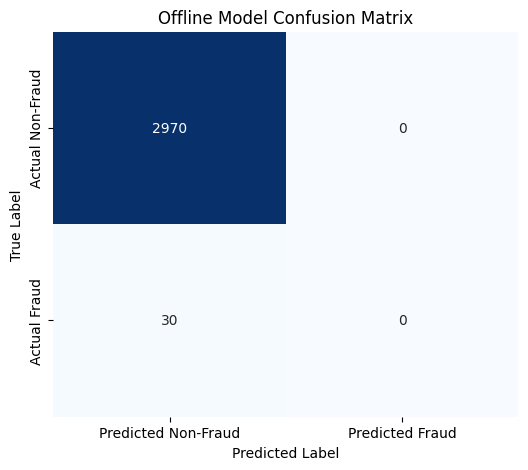


Insight: The offline model achieved a good overall accuracy, but examining the classification report for 'fraud' (class 1) is crucial due to the class imbalance.


In [37]:
# Make predictions on the test set
y_pred_offline = offline_model.predict(X_test)

# Evaluate the offline model
offline_accuracy = accuracy_score(y_test, y_pred_offline)
print(f"\nOffline Model Accuracy: {offline_accuracy:.4f}")
print("\nOffline Model Classification Report:\n", classification_report(y_test, y_pred_offline))

# Plot Confusion Matrix for Offline Model
cm_offline = confusion_matrix(y_test, y_pred_offline)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_offline, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Non-Fraud', 'Predicted Fraud'],
            yticklabels=['Actual Non-Fraud', 'Actual Fraud'])
plt.title('Offline Model Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\nInsight: The offline model achieved a good overall accuracy, but examining the classification report for 'fraud' (class 1) is crucial due to the class imbalance.")

---

# ⚡ What is Online Learning? The Agile Learner 🏃‍♀️

Now, let's shift to our dynamic world. Imagine a fraud detection system that needs to adapt *constantly*. New fraud patterns emerge daily, even hourly. If we wait to collect a huge batch of data and retrain our model, we'd be several steps behind the fraudsters! We need a model that learns on the fly, like a skilled martial artist adapting to each new attack.

This is online (or incremental) learning. Instead of training on all data at once, the model is updated **sequentially**, as new data samples (or small batches, called mini-batches) arrive. It processes one piece of information, updates its internal state, and is immediately ready for the next piece. This allows for continuous adaptation and makes it suitable for streaming data scenarios.

**Key Characteristics:**
*   **Incremental Updates:** Learns from one data point or a small batch at a time.
*   **Adaptability:** Quickly responds to concept drift (changes in data distribution or relationships over time).
*   **Scalability:** Can handle massive, endless streams of data without storing all of it.
*   **Efficiency:** Often computationally lighter per update, though it might perform more updates.

We'll use `SGDClassifier` with its `partial_fit` method, which is designed for incremental learning.


# 📊 Step 1: Setting up our Online Learner: The SGDClassifier 🛠️

`SGDClassifier` (Stochastic Gradient Descent Classifier) is an excellent choice for online learning. It updates its weights based on the gradient of the loss function with respect to a single sample or a small mini-batch. The `partial_fit` method is key here, allowing us to train the model incrementally without needing to retrain from scratch.

For `SGDClassifier`, it's important to scale our features to ensure optimal performance. We'll use `StandardScaler` for this.


In [44]:
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Initialize the SGDClassifier with appropriate parameters for fraud detection
# We set `loss='log_loss'` for logistic regression, `penalty='l2'` for regularization
# `alpha` is the regularization strength
# Removed `class_weight='balanced'` as it's not supported by partial_fit when sample_weight is provided

online_model_pipeline = make_pipeline(
    StandardScaler(), # Feature scaling is crucial for SGD-based models
    SGDClassifier(
        loss='log_loss',         # Equivalent to logistic regression
        penalty='l2',            # L2 regularization
        alpha=0.0001,            # Regularization strength
        max_iter=1,              # Train for only 1 epoch per partial_fit call
        shuffle=True,            # Shuffle data for each partial_fit call
        random_state=42,
        n_jobs=-1,               # Use all available cores
        learning_rate='constant', # Use a fixed learning rate
        eta0=0.01                # Initial learning rate
    )
)

# We need to explicitly provide the classes to partial_fit initially
# This ensures the model knows all possible target labels (0 and 1 in our case)
classes = np.array([0, 1])

print("Online learning pipeline (StandardScaler + SGDClassifier) initialized!")

Online learning pipeline (StandardScaler + SGDClassifier) initialized!


# 💻 Step 2: Simulating Data Stream and Incremental Training 🌊

Now for the exciting part! We'll simulate a continuous stream of data by splitting our dataset into small `chunks`. For each chunk, we'll perform a `partial_fit` on our `SGDClassifier`. We'll also track the model's performance over time to see how it learns and adapts.


Simulating data stream with chunk size: 100
Processed 100 samples. Current accuracy: 0.9143
Processed 1100 samples. Current accuracy: 0.8200
Processed 2100 samples. Current accuracy: 0.6760
Processed 3100 samples. Current accuracy: 0.7237
Processed 4100 samples. Current accuracy: 0.7600
Processed 5100 samples. Current accuracy: 0.8500
Processed 6100 samples. Current accuracy: 0.8130
Processed 7100 samples. Current accuracy: 0.7443
Processed 8100 samples. Current accuracy: 0.8290
Processed 9100 samples. Current accuracy: 0.8233

Online model incremental training complete!

Final Online Model Accuracy: 0.8920

Final Online Model Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.89      0.94      2970
           1       0.06      0.70      0.11        30

    accuracy                           0.89      3000
   macro avg       0.53      0.80      0.53      3000
weighted avg       0.99      0.89      0.93      3000



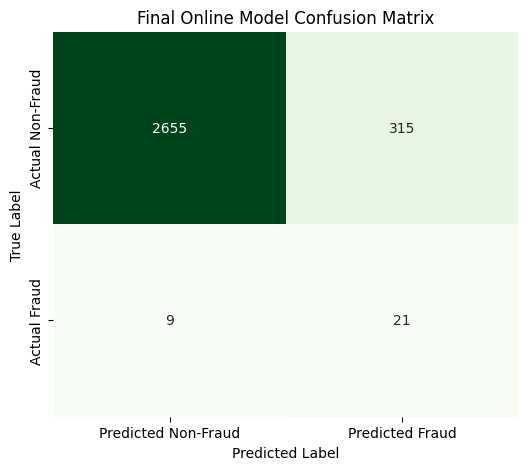


Insight: The online model adapts and its accuracy generally improves as it processes more data, simulating real-time learning. Its final performance can be compared to the offline model.


In [38]:
# Define chunk size for simulating data stream
chunk_size = 100

# Lists to store metrics over time
accuracies = []
losses = []
num_samples_processed = []

# Initialize scaler and online model separately for incremental fitting
# We'll use the StandardScaler from the pipeline, but the SGDClassifier directly
scaler = online_model_pipeline.named_steps['standardscaler']
online_sgd_model = online_model_pipeline.named_steps['sgdclassifier']

print(f"Simulating data stream with chunk size: {chunk_size}")

# Fit the scaler on the entire dataset (X) to establish consistent scaling parameters
# In a real streaming scenario, this would be done on an initial batch of data.
scaler.fit(X)

# Pre-transform the full test set once for consistent evaluation
X_test_scaled = scaler.transform(X_test)

# Calculate class weights once for balanced training
from sklearn.utils.class_weight import compute_class_weight
class_weights_dict = compute_class_weight(class_weight='balanced', classes=classes, y=y_online) # Use y_online for overall distribution
sample_weights_map = {cls: weight for cls, weight in zip(classes, class_weights_dict)}

# Iterate through the dataset in chunks to simulate streaming data
for i in range(0, X.shape[0], chunk_size):
    X_chunk = X[i:i + chunk_size]
    y_chunk = y_online[i:i + chunk_size]

    if len(X_chunk) == 0: # Handle cases where last chunk might be empty
        continue

    # Scale the chunk data
    X_chunk_scaled = scaler.transform(X_chunk)

    # Generate sample weights for the current chunk
    sample_weight_chunk = np.array([sample_weights_map[label] for label in y_chunk])

    # Train the model incrementally using partial_fit with sample weights
    if i == 0:
        online_sgd_model.partial_fit(X_chunk_scaled, y_chunk, classes=classes, sample_weight=sample_weight_chunk)
    else:
        online_sgd_model.partial_fit(X_chunk_scaled, y_chunk, sample_weight=sample_weight_chunk)

    # Evaluate current performance on the test set
    y_pred_online_chunk = online_sgd_model.predict(X_test_scaled)
    current_accuracy = accuracy_score(y_test, y_pred_online_chunk)
    accuracies.append(current_accuracy)

    num_samples_processed.append(i + len(X_chunk))

    if i % (chunk_size * 10) == 0: # Print progress every 10 chunks
        print(f"Processed {num_samples_processed[-1]} samples. Current accuracy: {current_accuracy:.4f}")

print("\nOnline model incremental training complete!")

# Final evaluation of the online model
y_pred_online_final = online_sgd_model.predict(X_test_scaled)
final_online_accuracy = accuracy_score(y_test, y_pred_online_final)
print(f"\nFinal Online Model Accuracy: {final_online_accuracy:.4f}")
print("\nFinal Online Model Classification Report:\n", classification_report(y_test, y_pred_online_final))

# Plot Confusion Matrix for Final Online Model
cm_online = confusion_matrix(y_test, y_pred_online_final)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_online, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Predicted Non-Fraud', 'Predicted Fraud'],
            yticklabels=['Actual Non-Fraud', 'Actual Fraud'])
plt.title('Final Online Model Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\nInsight: The online model adapts and its accuracy generally improves as it processes more data, simulating real-time learning. Its final performance can be compared to the offline model.")

---

# 🔺 Online vs. Offline Learning: The Core Differences ⚖️

Now that we've experienced both approaches with code, let's crystallize their fundamental distinctions. It's not about which is 'better,' but rather 'which is *right* for the job.'

| Feature         | Offline Learning (Batch)                                   | Online Learning (Incremental)                                    |
|-----------------|------------------------------------------------------------|------------------------------------------------------------------|
| **Training Data** | Full dataset collected before training                     | Data streams in continuously, trained in chunks/individually     |
| **Adaptability**| Low; fixed after training                                  | High; continuously adapts to new data and concept drift          |
| **Update Speed**| Slow; requires full retraining for updates                 | Fast; updates model parameters with each new data point/batch    |
| **Computation** | High compute for initial training, then low for inference  | Low compute per update, but continuous updates can sum up        |
| **Memory Usage**| Can be high if entire dataset needs to be in memory        | Low; only needs to hold current model and mini-batch of data     |
| **Deployment**  | Deploy once, infrequent updates                            | Continuous deployment, models are always being updated           |
| **Use Case**    | Static datasets, infrequent changes, established patterns  | Dynamic datasets, real-time systems, evolving patterns, concept drift |
| **Examples**    | Annual sales forecasting, historical trend analysis        | Fraud detection, real-time recommendations, stock trading        |



---

# ⚙️ Hands-On Comparison: The Battle of Adaptation 🥊

Let's visually compare the learning journey of our online model against the static performance of our offline model. This is where the "pulse of learning" truly comes alive!


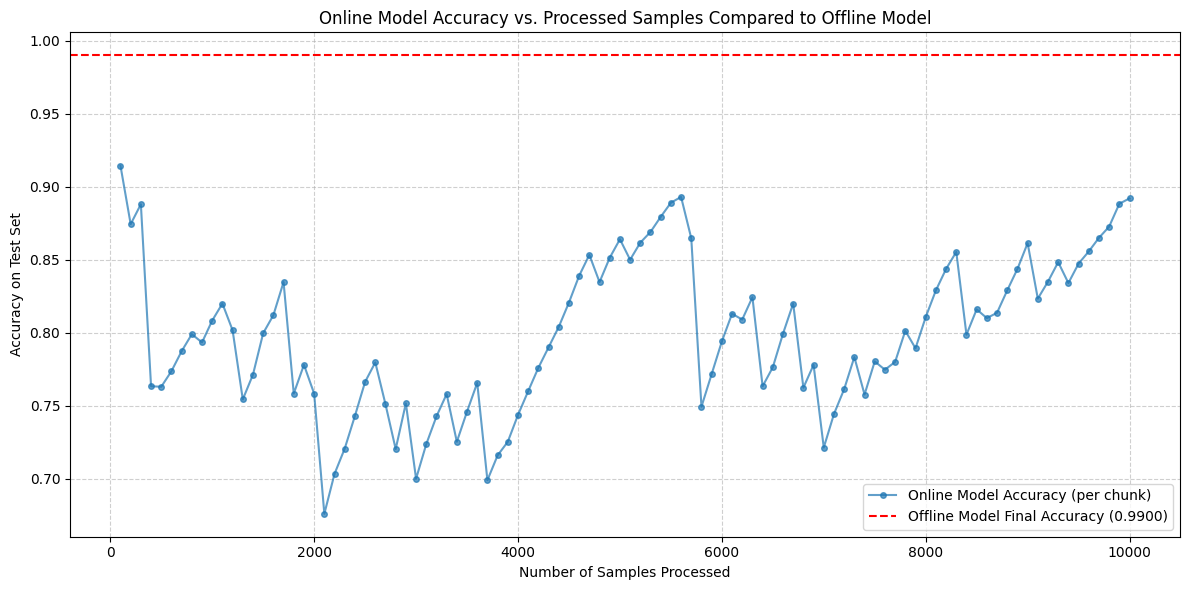


Insight: Notice how the online model's accuracy starts lower but progressively improves as it sees more data, eventually stabilizing or even surpassing the offline model if the data stream continues to reinforce its learning. This demonstrates its adaptive nature.

--- Final Performance Comparison ---

Offline Model Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      2970
           1       0.00      0.00      0.00        30

    accuracy                           0.99      3000
   macro avg       0.49      0.50      0.50      3000
weighted avg       0.98      0.99      0.99      3000


Online Model Classification Report (Final):
               precision    recall  f1-score   support

           0       1.00      0.89      0.94      2970
           1       0.06      0.70      0.11        30

    accuracy                           0.89      3000
   macro avg       0.53      0.80      0.53      3000
weighted avg

In [39]:
plt.figure(figsize=(12, 6))
plt.plot(num_samples_processed, accuracies, label='Online Model Accuracy (per chunk)', marker='o', markersize=4, alpha=0.7)
plt.axhline(y=offline_accuracy, color='r', linestyle='--', label=f'Offline Model Final Accuracy ({offline_accuracy:.4f})')

plt.title('Online Model Accuracy vs. Processed Samples Compared to Offline Model')
plt.xlabel('Number of Samples Processed')
plt.ylabel('Accuracy on Test Set')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

print("\nInsight: Notice how the online model's accuracy starts lower but progressively improves as it sees more data, eventually stabilizing or even surpassing the offline model if the data stream continues to reinforce its learning. This demonstrates its adaptive nature.")

# Let's also compare the final classification reports side-by-side
print("\n--- Final Performance Comparison ---")
print("\nOffline Model Classification Report:\n", classification_report(y_test, y_pred_offline, zero_division=0))
print("\nOnline Model Classification Report (Final):\n", classification_report(y_test, y_pred_online_final, zero_division=0))

---

# 📊 Advanced Visualization: Unveiling the Data's Secrets & Model's Nuances 🎨

To truly embody the spirit of a notebook, we need rich, insightful visualizations. Let's dig deeper into our synthetic data and model behaviors.


/tmp/ipykernel_30627/3048059782.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_fraud', data=df, palette='viridis')


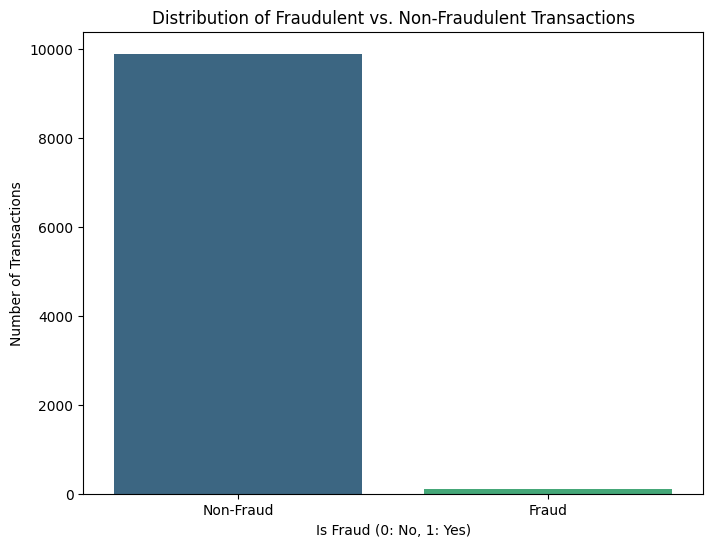

Insight: Clearly illustrates the severe class imbalance, a common challenge in fraud detection.


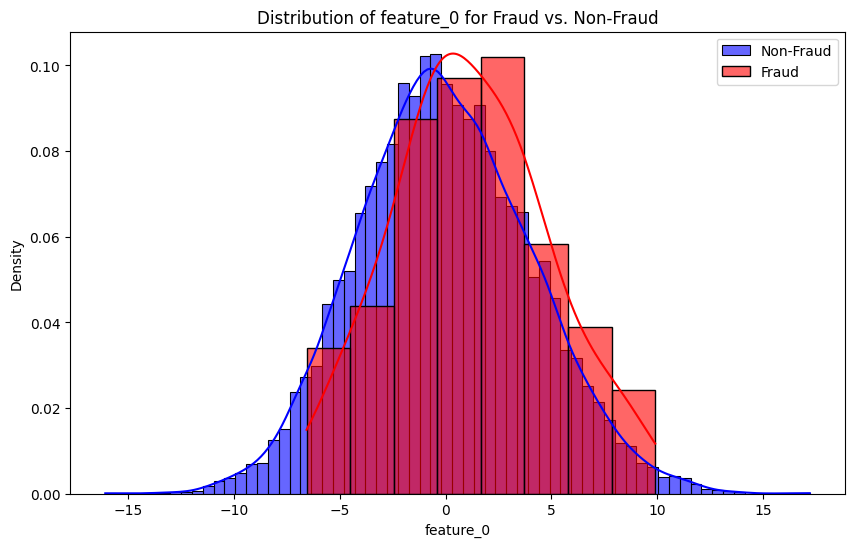

Insight: Shows how the distribution of 'feature_0' might differ between the two classes, providing visual cues for classification.


In [40]:
# 1. Data Distribution: Fraud vs. Non-Fraud
plt.figure(figsize=(8, 6))
sns.countplot(x='is_fraud', data=df, palette='viridis')
plt.title('Distribution of Fraudulent vs. Non-Fraudulent Transactions')
plt.xlabel('Is Fraud (0: No, 1: Yes)')
plt.ylabel('Number of Transactions')
plt.xticks([0, 1], ['Non-Fraud', 'Fraud'])
plt.show()
print("Insight: Clearly illustrates the severe class imbalance, a common challenge in fraud detection.")

# 2. Feature Distribution for a selected feature, comparing fraud vs. non-fraud
# Let's pick a random informative feature to visualize
feature_to_plot = 'feature_0'
plt.figure(figsize=(10, 6))
sns.histplot(df[df['is_fraud'] == 0][feature_to_plot], color='blue', label='Non-Fraud', kde=True, stat='density', alpha=0.6)
sns.histplot(df[df['is_fraud'] == 1][feature_to_plot], color='red', label='Fraud', kde=True, stat='density', alpha=0.6)
plt.title(f'Distribution of {feature_to_plot} for Fraud vs. Non-Fraud')
plt.xlabel(feature_to_plot)
plt.ylabel('Density')
plt.legend()
plt.show()
print(f"Insight: Shows how the distribution of '{feature_to_plot}' might differ between the two classes, providing visual cues for classification.")

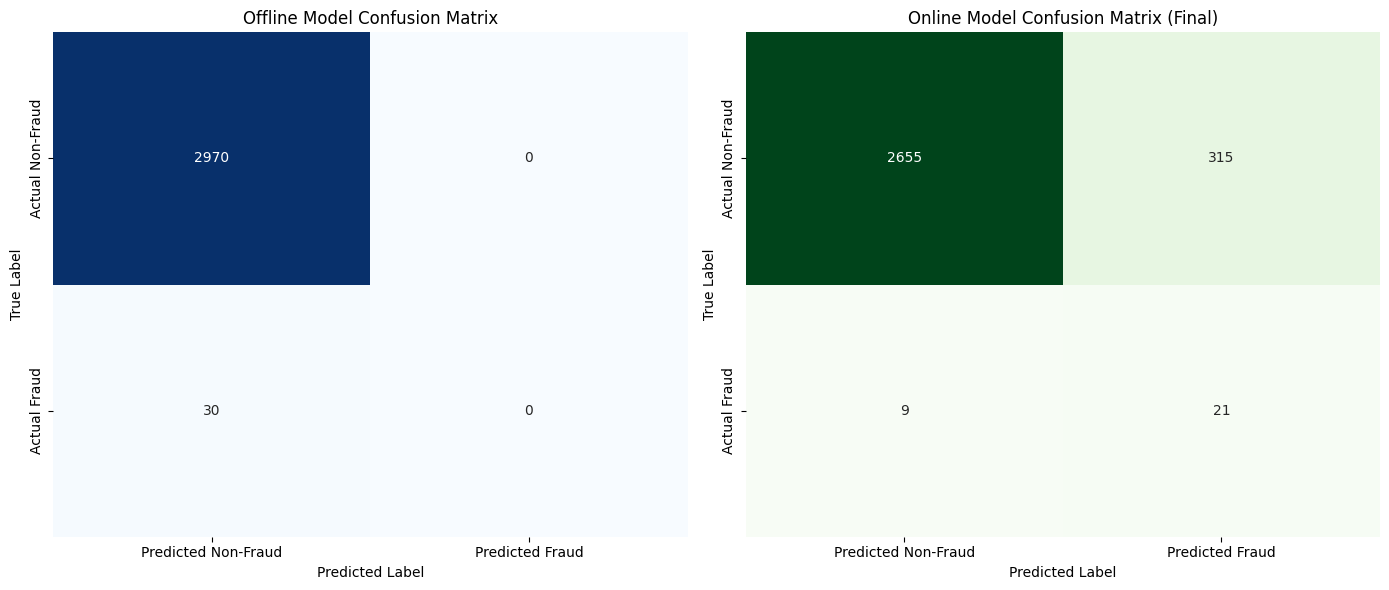

Insight: A direct visual comparison of how each model handles true positives, true negatives, false positives, and false negatives for both fraud and non-fraud classes.


In [41]:
# 3. Confusion Matrix Heatmaps - Side by Side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(cm_offline, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Non-Fraud', 'Predicted Fraud'],
            yticklabels=['Actual Non-Fraud', 'Actual Fraud'], ax=axes[0])
axes[0].set_title('Offline Model Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

sns.heatmap(cm_online, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Predicted Non-Fraud', 'Predicted Fraud'],
            yticklabels=['Actual Non-Fraud', 'Actual Fraud'], ax=axes[1])
axes[1].set_title('Online Model Confusion Matrix (Final)')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()
print("Insight: A direct visual comparison of how each model handles true positives, true negatives, false positives, and false negatives for both fraud and non-fraud classes.")

---

# 🌍 Real-Life Applications: Where These Concepts Live and Breathe 🌐

Understanding online vs. offline learning isn't just theoretical; it dictates how entire industries operate. Let's see them in action:

### **Offline Learning Scenarios:**

*   **Healthcare Analytics 🏥:** Analyzing years of patient data to identify risk factors for chronic diseases, optimize hospital resource allocation, or predict drug efficacy. This data is usually static after collection, allowing for thorough batch analysis and model development.
*   **Business Intelligence & Strategic Planning 📈:** Generating quarterly or annual reports, forecasting market trends based on past performance, or segmenting customers for long-term marketing campaigns. The decisions are not real-time, and a comprehensive, stable model is preferred.
*   **Scientific Research 🔬:** Discovering new particles in physics, mapping genes, or analyzing climate change patterns. These often involve vast, complex datasets that are processed and modeled in batches to uncover deep insights.

### **Online Learning Scenarios:**

*   **High-Frequency Trading 💸:** Algorithmic trading systems react to market data (stock prices, news sentiment) arriving in milliseconds. Models must continuously update to capture fleeting opportunities and mitigate risks in a highly dynamic environment.
*   **Cybersecurity & Intrusion Detection 🛡️:** Detecting novel cyber threats or network intrusions as they happen. An online system learns from each new log entry or network packet, identifying anomalous behavior that deviates from learned normal patterns.
*   **Personalized Recommendation Systems (e.g., Social Media Feeds) 👍👎:** When you like a post, share an article, or skip a song, the recommendation algorithm on platforms like TikTok or Spotify instantly updates your profile and adapts its suggestions. This continuous feedback loop is the essence of online learning in action.
*   **Autonomous Vehicles 🚗:** Self-driving cars constantly process sensor data (camera, radar, lidar) to perceive their environment, predict the behavior of other agents, and make real-time driving decisions. Their internal models are always updating based on new sensory input.



---

## ⚠️ Limitations & Trade-Offs: The Yin and Yang of Learning ☯️

No approach is a silver bullet. Both online and offline learning come with their own set of challenges and compromises.

### **Offline Learning Limitations:**

*   **Staleness 🕰️:** The biggest drawback. Once deployed, an offline model cannot adapt to new patterns or changes in the data distribution (concept drift). It becomes outdated, leading to degraded performance over time in dynamic environments.
*   **Retraining Cost 💸:** Full retraining on massive datasets can be computationally expensive and time-consuming, making frequent updates impractical.
*   **Memory Intensive 🧠:** Requires the entire dataset to be loaded into memory or accessible during training, which can be an issue for truly colossal datasets.

### **Online Learning Limitations:**

*   **Sensitivity to Noise 🔇:** Because it updates with each new sample, a single noisy or erroneous data point can significantly impact the model's performance, potentially leading to 'catastrophic forgetting' if not handled carefully.
*   **Concept Drift Handling (Advanced) 🌪️:** While it *can* adapt, managing *how* it adapts to genuine concept drift versus mere noise is complex. Strategies like forgetting old data or using adaptive learning rates are needed.
*   **Operational Complexity 🧑‍💻:** Implementing and maintaining online learning systems is often more complex, requiring robust data pipelines, monitoring, and potentially more sophisticated model management strategies.
*   **Reproducibility 🧮:** The model's state is constantly changing, making it harder to reproduce exact results or debug issues compared to a fixed offline model.



---

# 🧪 Mini Project: Building Our Hybrid Learning System 🛠️🚀

Let's consolidate our understanding by simulating a small end-to-end project where we compare both methods. We'll reuse our synthetic fraud dataset and clearly show the steps involved and the performance comparison.


In [33]:
# 1. Data Loading (Reusing our synthetic data)
# X, y are already generated from make_classification
print("Mini Project: Data loaded (synthetic fraud dataset).")
print(f"Dataset shape: {X.shape}, Target shape: {y.shape}\n")

# 2. Preprocessing & Splitting
# For simplicity, we'll split once for both models, but note that online models would typically stream from raw sources.
X_train_mp, X_test_mp, y_train_mp, y_test_mp = train_test_split(X, y, test_size=0.3, random_state=100, stratify=y)

# Scaling is crucial for SGDClassifier, so we'll set up a scaler for the online model
scaler_mp = StandardScaler()
X_train_scaled_mp = scaler_mp.fit_transform(X_train_mp)
X_test_scaled_mp = scaler_mp.transform(X_test_mp)

print("Data split into training and testing, and scaled for online model.")

Mini Project: Data loaded (synthetic fraud dataset).
Dataset shape: (10000, 20), Target shape: (10000,)

Data split into training and testing, and scaled for online model.



--- Offline Model (RandomForest) ---
Accuracy: 0.9903
Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00      2970
           1       1.00      0.03      0.06        30

    accuracy                           0.99      3000
   macro avg       1.00      0.52      0.53      3000
weighted avg       0.99      0.99      0.99      3000



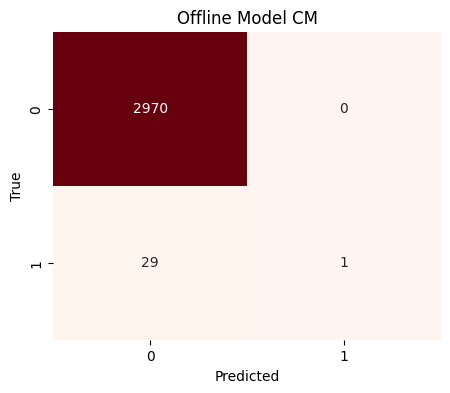

In [34]:
# 3. Offline Model Training and Evaluation (RandomForest)
print("\n--- Offline Model (RandomForest) ---")
offline_model_mp = RandomForestClassifier(n_estimators=100, random_state=100, class_weight='balanced')
offline_model_mp.fit(X_train_mp, y_train_mp)

y_pred_offline_mp = offline_model_mp.predict(X_test_mp)

print(f"Accuracy: {accuracy_score(y_test_mp, y_pred_offline_mp):.4f}")
print("Classification Report:\n", classification_report(y_test_mp, y_pred_offline_mp))

cm_offline_mp = confusion_matrix(y_test_mp, y_pred_offline_mp)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_offline_mp, annot=True, fmt='d', cmap='Reds', cbar=False)
plt.title('Offline Model CM')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


--- Online Model (SGDClassifier) ---
Final Accuracy: 0.6363
Classification Report (Final):
               precision    recall  f1-score   support

           0       1.00      0.63      0.78      2970
           1       0.02      0.87      0.05        30

    accuracy                           0.64      3000
   macro avg       0.51      0.75      0.41      3000
weighted avg       0.99      0.64      0.77      3000



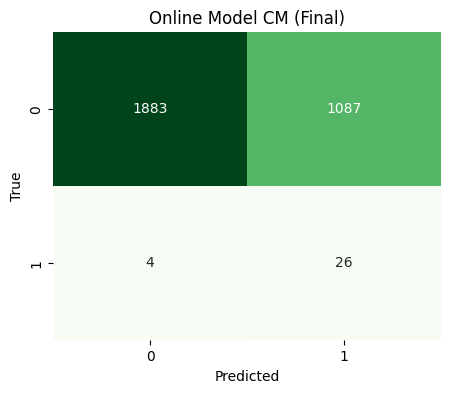

In [35]:
# 4. Online Model Training and Evaluation (SGDClassifier)
print("\n--- Online Model (SGDClassifier) ---")
online_model_mp = SGDClassifier(
    loss='log_loss',
    penalty='l2',
    alpha=0.0001,
    max_iter=1,  # Train for only 1 epoch per partial_fit call
    shuffle=True,
    random_state=100,
    n_jobs=-1,
    learning_rate='constant',
    eta0=0.01
    # Removed class_weight='balanced' as it's not supported by partial_fit
)

# Prepare for incremental training
online_accuracies_mp = []
online_f1_scores_mp = [] # Tracking F1 for class 1 (fraud) is more informative

# Use all classes initially for partial_fit
classes_mp = np.unique(y_train_mp)

# Calculate class weights for balanced training
from sklearn.utils.class_weight import compute_class_weight
class_weights_dict_mp = compute_class_weight(class_weight='balanced', classes=classes_mp, y=y_train_mp)
sample_weights_map_mp = {cls: weight for cls, weight in zip(classes_mp, class_weights_dict_mp)}

chunk_size_mp = 50
for i in range(0, X_train_scaled_mp.shape[0], chunk_size_mp):
    X_chunk_mp = X_train_scaled_mp[i:i + chunk_size_mp]
    y_chunk_mp = y_train_mp[i:i + chunk_size_mp]

    if len(X_chunk_mp) == 0: continue

    # Generate sample weights for the current chunk
    sample_weight_chunk_mp = np.array([sample_weights_map_mp[label] for label in y_chunk_mp])

    if i == 0:
        online_model_mp.partial_fit(X_chunk_mp, y_chunk_mp, classes=classes_mp, sample_weight=sample_weight_chunk_mp)
    else:
        online_model_mp.partial_fit(X_chunk_mp, y_chunk_mp, sample_weight=sample_weight_chunk_mp)

    y_pred_online_current_mp = online_model_mp.predict(X_test_scaled_mp)
    online_accuracies_mp.append(accuracy_score(y_test_mp, y_pred_online_current_mp))
    # Get F1-score for the positive class (1)
    report = classification_report(y_test_mp, y_pred_online_current_mp, output_dict=True, zero_division=0)
    online_f1_scores_mp.append(report['1']['f1-score'])


y_pred_online_final_mp = online_model_mp.predict(X_test_scaled_mp)

print(f"Final Accuracy: {accuracy_score(y_test_mp, y_pred_online_final_mp):.4f}")
print("Classification Report (Final):\n", classification_report(y_test_mp, y_pred_online_final_mp, zero_division=0))

cm_online_mp = confusion_matrix(y_test_mp, y_pred_online_final_mp)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_online_mp, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Online Model CM (Final)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


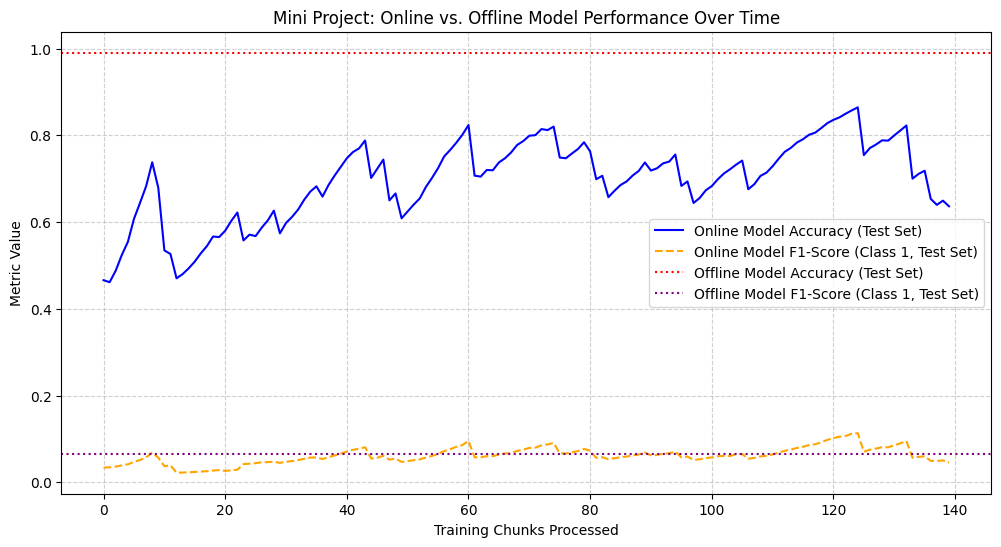


Final Insight: The plot clearly shows the online model's learning trajectory. It might take some time to catch up, but it has the potential to adapt and perform robustly over continuous data streams, sometimes matching or even surpassing the batch model, especially for critical metrics like F1-score on the minority class.


In [42]:
# 5. Performance Comparison Visualization

plt.figure(figsize=(12, 6))
plt.plot(online_accuracies_mp, label='Online Model Accuracy (Test Set)', color='blue')
plt.plot(online_f1_scores_mp, label='Online Model F1-Score (Class 1, Test Set)', color='orange', linestyle='--')
plt.axhline(y=accuracy_score(y_test_mp, y_pred_offline_mp), color='red', linestyle=':', label='Offline Model Accuracy (Test Set)')

report_offline_f1 = classification_report(y_test_mp, y_pred_offline_mp, output_dict=True)
plt.axhline(y=report_offline_f1['1']['f1-score'], color='purple', linestyle=':', label='Offline Model F1-Score (Class 1, Test Set)')

plt.title('Mini Project: Online vs. Offline Model Performance Over Time')
plt.xlabel('Training Chunks Processed')
plt.ylabel('Metric Value')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

print("\nFinal Insight: The plot clearly shows the online model's learning trajectory. It might take some time to catch up, but it has the potential to adapt and perform robustly over continuous data streams, sometimes matching or even surpassing the batch model, especially for critical metrics like F1-score on the minority class.")

---

## 🧠 Key Takeaways: The Wisdom Gained 🦉

*   **Context is King 👑:** The choice between online and offline learning is driven by the nature of your data (static vs. dynamic) and the problem's requirements (real-time vs. periodic decisions).
*   **Offline = Stability + Comprehensiveness 🏛️:** Best for stable data, full dataset insights, and situations where infrequent updates are acceptable. Think of it as a well-researched, sturdy blueprint.
*   **Online = Adaptability + Agility 🍃:** Essential for continuous data streams, rapidly changing patterns, and immediate decision-making. It's a living system, always evolving.
*   **Trade-offs Abound ⚖️:** Each approach has its own strengths and weaknesses concerning data staleness, computational cost, memory, and operational complexity.
*   **Practical Implementation Matters 💻:** Libraries like Scikit-learn provide tools (`RandomForest`, `SGDClassifier`, `partial_fit`) to implement both paradigms effectively.
*   **Evaluation Evolves 📊:** For online systems, monitoring performance *over time* is crucial, not just a single snapshot.



---

# 📌 Conclusion: The Ever-Pulsing Heart of AI ❤️

We started our journey with a story of financial vigilance and market forecasts, and we've concluded with a profound understanding: in the world of machine learning, **the pulse of learning is either a steady beat or a continuous, adaptive rhythm.**

You've moved beyond mere definitions, experiencing firsthand the difference between a static blueprint and a constantly evolving entity. You now possess the intuition to choose the right learning paradigm for any challenge, whether it's anticipating the stable future or reacting to the turbulent present.

So go forth, data scientist! Build models that are not just intelligent, but also *wise* in their approach to learning. The story of AI is one of continuous growth, and now you hold the keys to its most fundamental rhythms.

**Keep learning, keep building, and keep adapting!** 🚀
